In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
print(df.shape)

(7043, 21)


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].isna().sum())

11


In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(df['TotalCharges'].isna().sum())

0


In [12]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=['0-1 year', '1-2 years', '2-4 years', '4-5 years', '5-6 years']
)

df[['tenure', 'TenureGroup']].head()
df['IsLongTermCustomer'] = (df['tenure'] >= 24).astype(int)

df[['tenure', 'IsLongTermCustomer']].head()

,tenure,IsLongTermCustomer
0,1,0
1,34,1
2,2,0
3,45,1
4,2,0


In [13]:
df[['tenure', 'IsLongTermCustomer']].head()

,tenure,IsLongTermCustomer
0,1,0
1,34,1
2,2,0
3,45,1
4,2,0


In [14]:
df['IsLongTermCustomer'] = (df['tenure'] >= 24).astype(int)

df[['tenure', 'IsLongTermCustomer']].head()

,tenure,IsLongTermCustomer
0,1,0
1,34,1
2,2,0
3,45,1
4,2,0


In [15]:
df = pd.get_dummies(df, drop_first=True)

print(df.shape)

(7043, 7078)


In [16]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060

In [17]:
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

df[['TotalCharges', 'tenure', 'AvgMonthlySpend']].head()

,TotalCharges,tenure,AvgMonthlySpend
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000


In [18]:
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = (
    df[service_columns]
    .apply(lambda x: (x == 'Yes').sum(), axis=1)
)

df[['TotalServices']].head()

KeyError: "None of [Index(['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',\n       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'],\n      dtype='str')] are in the [columns]"

In [ ]:
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'IsLongTermCustomer']].head()

KeyError: "['IsLongTermCustomer'] not in index"

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Create long-term customer feature
df['IsLongTermCustomer'] = (df['tenure'] >= 24).astype(int)

# Define service columns
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Create total number of services
df['TotalServices'] = (
    df[service_columns]
    .apply(lambda x: (x == 'Yes').sum(), axis=1)
)

# Check the new features
df[['tenure', 'MonthlyCharges', 'TotalCharges',
   'TotalServices', 'IsLongTermCustomer']].head()

,tenure,MonthlyCharges,TotalCharges,TotalServices,IsLongTermCustomer
0,1,29.85,29.85,1,0
1,34,56.95,1889.50,3,1
2,2,53.85,108.15,3,0
3,45,42.30,1840.75,3,1
4,2,70.70,151.65,1,0


In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
churn_by_tenure = df.groupby('IsLongTermCustomer')['Churn'].agg(
    ['count', 'sum', 'mean']
)

churn_by_tenure.columns = [
    'TotalCustomers',
    'ChurnedCustomers',
    'ChurnRate'
]

churn_by_tenure['ChurnRate'] = churn_by_tenure['ChurnRate'] * 100

churn_by_tenure

,TotalCustomers,ChurnedCustomers,ChurnRate
IsLongTermCustomer,,,
0,3116,1308,41.976893
1,3927,561,14.285714


In [ ]:
churn_by_services = df.groupby('TotalServices')['Churn'].agg(
    ['count', 'sum', 'mean']
)

churn_by_services.columns = [
    'TotalCustomers',
    'ChurnedCustomers',
    'ChurnRate'
]

churn_by_services['ChurnRate'] = churn_by_services['ChurnRate'] * 100

churn_by_services

,TotalCustomers,ChurnedCustomers,ChurnRate
TotalServices,,,
0,80,35,43.750000
1,1701,359,21.105232
2,1188,390,32.828283
3,965,352,36.476684
4,922,289,31.344902
5,908,232,25.550661
6,676,152,22.485207
7,395,49,12.405063
8,208,11,5.288462


In [ ]:
churn_by_contract = df.groupby('Contract')['Churn'].agg(
    ['count', 'sum', 'mean']
)

churn_by_contract.columns = [
    'TotalCustomers',
    'ChurnedCustomers',
    'ChurnRate'
]

churn_by_contract['ChurnRate'] = churn_by_contract['ChurnRate'] * 100

churn_by_contract

,TotalCustomers,ChurnedCustomers,ChurnRate
Contract,,,
Month-to-month,3875,1655,42.709677
One year,1473,166,11.269518
Two year,1695,48,2.831858


In [ ]:
churn_by_payment = df.groupby('PaymentMethod')['Churn'].agg(
    ['count', 'sum', 'mean']
)

churn_by_payment.columns = [
    'TotalCustomers',
    'ChurnedCustomers',
    'ChurnRate'
]

churn_by_payment['ChurnRate'] = churn_by_payment['ChurnRate'] * 100

churn_by_payment

,TotalCustomers,ChurnedCustomers,ChurnRate
PaymentMethod,,,
Bank transfer (automatic),1544,258,16.709845
Credit card (automatic),1522,232,15.243101
Electronic check,2365,1071,45.285412
Mailed check,1612,308,19.106700


In [ ]:
df['MonthlyChargesGroup'] = pd.qcut(
    df['MonthlyCharges'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

churn_by_monthly_charge = df.groupby(
    'MonthlyChargesGroup',
    observed=True
)['Churn'].agg(['count', 'sum', 'mean'])

churn_by_monthly_charge.columns = [
    'TotalCustomers',
    'ChurnedCustomers',
    'ChurnRate'
]

churn_by_monthly_charge['ChurnRate'] = (
    churn_by_monthly_charge['ChurnRate'] * 100
)

churn_by_monthly_charge

,TotalCustomers,ChurnedCustomers,ChurnRate
MonthlyChargesGroup,,,
Low,1762,198,11.237230
Medium-Low,1766,434,24.575311
Medium-High,1757,659,37.507114
High,1758,578,32.878271


In [ ]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)

churn_by_tenure = df.groupby('TenureGroup', observed=True)['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

churn_by_tenure['ChurnRate'] = churn_by_tenure['ChurnRate'] * 100

churn_by_tenure

,TotalCustomers,ChurnedCustomers,ChurnRate
TenureGroup,,,
0-12 months,2175,1037,47.678161
13-24 months,1024,294,28.710938
25-48 months,1594,325,20.388959
49-72 months,2239,213,9.513176


In [ ]:
churn_by_senior = df.groupby('SeniorCitizen')['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

churn_by_senior['ChurnRate'] = churn_by_senior['ChurnRate'] * 100

churn_by_senior

,TotalCustomers,ChurnedCustomers,ChurnRate
SeniorCitizen,,,
0,5901,1393,23.606168
1,1142,476,41.681261


In [ ]:
churn_by_internet = df.groupby('InternetService')['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

churn_by_internet['ChurnRate'] = churn_by_internet['ChurnRate'] * 100

churn_by_internet

,TotalCustomers,ChurnedCustomers,ChurnRate
InternetService,,,
DSL,2421,459,18.959108
Fiber optic,3096,1297,41.892765
No,1526,113,7.404980


In [ ]:
churn_by_security = df.groupby('OnlineSecurity')['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

churn_by_security['ChurnRate'] = churn_by_security['ChurnRate'] * 100

churn_by_security

,TotalCustomers,ChurnedCustomers,ChurnRate
OnlineSecurity,,,
No,3498,1461,41.766724
No internet service,1526,113,7.404980
Yes,2019,295,14.611194


In [ ]:
df['AvgMonthlyCharge'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    df['MonthlyCharges']
)

In [ ]:
df['ChargeDifference'] = (
    df['MonthlyCharges'] - df['AvgMonthlyCharge']
)

df[['tenure', 'MonthlyCharges', 'TotalCharges',
   'AvgMonthlyCharge', 'ChargeDifference']].head()

,tenure,MonthlyCharges,TotalCharges,AvgMonthlyCharge,ChargeDifference
0,1,29.85,29.85,29.850000,0.000000
1,34,56.95,1889.50,55.573529,1.376471
2,2,53.85,108.15,54.075000,-0.225000
3,45,42.30,1840.75,40.905556,1.394444
4,2,70.70,151.65,75.825000,-5.125000


In [ ]:
print(df[['AvgMonthlyCharge', 'ChargeDifference']].describe())
print("\nMissing values:")
print(df[['AvgMonthlyCharge', 'ChargeDifference']].isnull().sum())

       AvgMonthlyCharge  ChargeDifference
count       7043.000000       7043.000000
mean          64.762906         -0.001213
std           30.189796          2.614121
min           13.775000        -18.900000
25%           35.935156         -1.159091
50%           70.337500          0.000000
75%           90.174158          1.145567
max          121.400000         19.125000

Missing values:
AvgMonthlyCharge    0
ChargeDifference    0
dtype: int64


In [ ]:
df['ChargeDifference'] = (
    df['MonthlyCharges'] - df['AvgMonthlyCharge']
)

df[['MonthlyCharges', 'AvgMonthlyCharge', 'ChargeDifference']].head()

,MonthlyCharges,AvgMonthlyCharge,ChargeDifference
0,29.85,29.850000,0.000000
1,56.95,55.573529,1.376471
2,53.85,54.075000,-0.225000
3,42.30,40.905556,1.394444
4,70.70,75.825000,-5.125000


In [ ]:
service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = 0

for col in service_cols:
    df['TotalServices'] += (df[col] == 'Yes').astype(int)

df[['TotalServices', 'Churn']].head()

,TotalServices,Churn
0,1,0
1,3,0
2,3,1
3,3,0
4,1,1


In [ ]:
df.groupby('TotalServices')['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

,TotalCustomers,ChurnedCustomers,ChurnRate
TotalServices,,,
0,80,35,0.437500
1,1701,359,0.211052
2,1188,390,0.328283
3,965,352,0.364767
4,922,289,0.313449
5,908,232,0.255507
6,676,152,0.224852
7,395,49,0.124051
8,208,11,0.052885


In [ ]:
df['TotalServices'].describe()

count    7043.000000
mean        3.362914
std         2.062031
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: TotalServices, dtype: float64

In [ ]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, np.inf],
    labels=['0-12 months', '13-24 months', '25-48 months', '49+ months']
)

df[['tenure', 'TenureGroup']].head()

,tenure,TenureGroup
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months


In [ ]:
df.groupby('TenureGroup', observed=False)['Churn'].agg(
    TotalCustomers='count',
    ChurnedCustomers='sum',
    ChurnRate='mean'
)

,TotalCustomers,ChurnedCustomers,ChurnRate
TenureGroup,,,
0-12 months,2186,1037,0.474382
13-24 months,1024,294,0.287109
25-48 months,1594,325,0.203890
49+ months,2239,213,0.095132


In [ ]:
engineered_features = [
    'AvgMonthlyCharge',
    'ChargeDifference',
    'TotalServices',
    'TenureGroup'
]

df[engineered_features].head()

,AvgMonthlyCharge,ChargeDifference,TotalServices,TenureGroup
0,29.850000,0.000000,1,0-12 months
1,55.573529,1.376471,3,25-48 months
2,54.075000,-0.225000,3,0-12 months
3,40.905556,1.394444,3,25-48 months
4,75.825000,-5.125000,1,0-12 months


In [ ]:
print("Missing values:")
print(df[engineered_features].isnull().sum())

Missing values:
AvgMonthlyCharge    0
ChargeDifference    0
TotalServices       0
TenureGroup         0
dtype: int64


In [ ]:
print("New columns:")
print(engineered_features)

New columns:
['AvgMonthlyCharge', 'ChargeDifference', 'TotalServices', 'TenureGroup']


In [ ]:
df[['AvgMonthlyCharge', 'ChargeDifference', 'TotalServices', 'TenureGroup']].head(10)

,AvgMonthlyCharge,ChargeDifference,TotalServices,TenureGroup
0,29.850000,0.000000,1,0-12 months
1,55.573529,1.376471,3,25-48 months
2,54.075000,-0.225000,3,0-12 months
3,40.905556,1.394444,3,25-48 months
4,75.825000,-5.125000,1,0-12 months
5,102.562500,-2.912500,5,0-12 months
6,88.609091,0.490909,4,13-24 months
7,30.190000,-0.440000,1,0-12 months
8,108.787500,-3.987500,6,25-48 months
9,56.257258,-0.107258,3,49+ months


In [ ]:
df[['AvgMonthlyCharge', 'ChargeDifference', 'TotalServices']].describe()

,AvgMonthlyCharge,ChargeDifference,TotalServices
count,7043.000000,7043.000000,7043.000000
mean,64.762906,-0.001213,3.362914
std,30.189796,2.614121,2.062031
min,13.775000,-18.900000,0.000000
25%,35.935156,-1.159091,1.000000
50%,70.337500,0.000000,3.000000
75%,90.174158,1.145567,5.000000
max,121.400000,19.125000,8.000000


In [ ]:
print("Dataset shape:", df.shape)
print("Missing values in engineered features:")
print(df[engineered_features].isnull().sum())

Dataset shape: (7043, 27)
Missing values in engineered features:
AvgMonthlyCharge    0
ChargeDifference    0
TotalServices       0
TenureGroup         0
dtype: int64


In [ ]:
df[['TotalServices']].describe()

,TotalServices
count,7043.000000
mean,3.362914
std,2.062031
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,8.000000


In [ ]:
df['TotalServices'].value_counts().sort_index()

TotalServices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

In [ ]:
df.groupby('Churn')[engineered_features].mean()

TypeError: category dtype does not support aggregation 'mean'

In [ ]:
print(df[engineered_features].dtypes)

AvgMonthlyCharge     float64
ChargeDifference     float64
TotalServices          int64
TenureGroup         category
dtype: object


In [ ]:
print(df[engineered_features].dtypes)
print(df[engineered_features].isnull().sum())

AvgMonthlyCharge     float64
ChargeDifference     float64
TotalServices          int64
TenureGroup         category
dtype: object
AvgMonthlyCharge    0
ChargeDifference    0
TotalServices       0
TenureGroup         0
dtype: int64


In [ ]:
numeric_engineered_features = [
    'AvgMonthlyCharge',
    'ChargeDifference',
    'TotalServices'
]

df.groupby('Churn')[numeric_engineered_features].mean()

,AvgMonthlyCharge,ChargeDifference,TotalServices
Churn,,,
0,61.269730,-0.004606,3.446270
1,74.433154,0.008178,3.132156


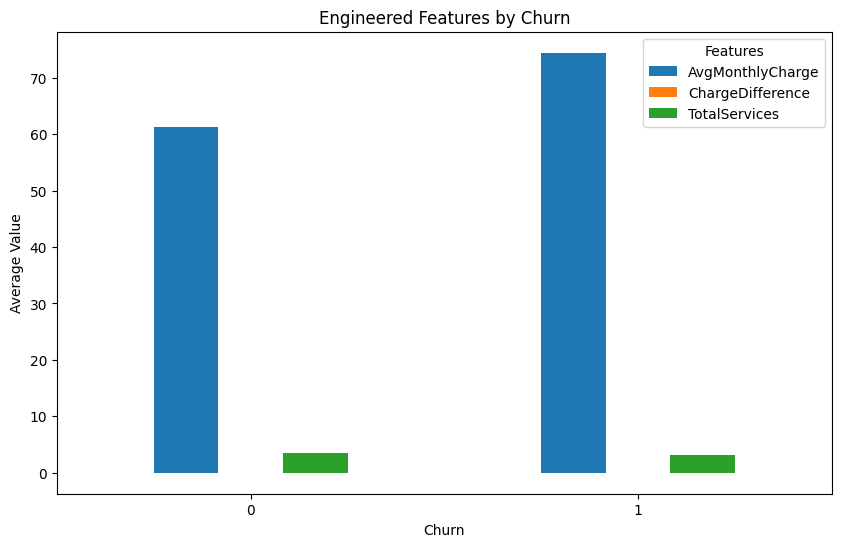

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Churn')[numeric_engineered_features].mean().plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Engineered Features by Churn')
plt.xlabel('Churn')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Features')
plt.show()

In [ ]:
df.groupby('Churn')[numeric_engineered_features].mean().round(2)

,AvgMonthlyCharge,ChargeDifference,TotalServices
Churn,,,
0,61.27,-0.00,3.45
1,74.43,0.01,3.13


In [ ]:
df[numeric_engineered_features + ['Churn']].corr()['Churn'].sort_values(ascending=False)

Churn               1.000000
AvgMonthlyCharge    0.192531
ChargeDifference    0.002159
TotalServices      -0.067264
Name: Churn, dtype: float64

In [ ]:
numeric_features = df.select_dtypes(include='number').columns

df[numeric_features].corr()['Churn'].sort_values(ascending=False)

Churn                 1.000000
MonthlyCharges        0.193356
AvgMonthlyCharge      0.192531
SeniorCitizen         0.150889
ChargeDifference      0.002159
TotalServices        -0.067264
TotalCharges         -0.199484
IsLongTermCustomer   -0.311496
tenure               -0.352229
Name: Churn, dtype: float64

In [ ]:
categorical_features = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

categorical_features

C:\Users\tamir\AppData\Local\Temp\ipykernel_27356\1001164715.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyChargesGroup',
 'TenureGroup']

In [ ]:
categorical_features = [
    col for col in categorical_features
    if col != 'CustomerID'
]

print(categorical_features)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyChargesGroup', 'TenureGroup']


In [ ]:
for col in categorical_features:
    print(f"\n{col}")
    print(
        pd.crosstab(
            df[col],
            df['Churn'],
            normalize='index'
        ).round(3)
    )


customerID
Churn         0    1
customerID          
0002-ORFBO  1.0  0.0
0003-MKNFE  1.0  0.0
0004-TLHLJ  0.0  1.0
0011-IGKFF  0.0  1.0
0013-EXCHZ  0.0  1.0
...         ...  ...
9987-LUTYD  1.0  0.0
9992-RRAMN  0.0  1.0
9992-UJOEL  1.0  0.0
9993-LHIEB  1.0  0.0
9995-HOTOH  1.0  0.0

[7043 rows x 2 columns]

gender
Churn       0      1
gender              
Female  0.731  0.269
Male    0.738  0.262

Partner
Churn        0      1
Partner              
No       0.670  0.330
Yes      0.803  0.197

Dependents
Churn           0      1
Dependents              
No          0.687  0.313
Yes         0.845  0.155

PhoneService
Churn             0      1
PhoneService              
No            0.751  0.249
Yes           0.733  0.267

MultipleLines
Churn                 0      1
MultipleLines                 
No                0.750  0.250
No phone service  0.751  0.249
Yes               0.714  0.286

InternetService
Churn                0      1
InternetService              
DSL              0.8

In [ ]:
categorical_features = [
    col for col in categorical_features
    if col != 'customerID'
]

print(categorical_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyChargesGroup', 'TenureGroup']


In [ ]:
for col in categorical_features:
    print(f"\n{col}")
    print(
        pd.crosstab(
            df[col],
            df['Churn'],
            normalize='index'
        ).round(3)
    )


gender
Churn       0      1
gender              
Female  0.731  0.269
Male    0.738  0.262

Partner
Churn        0      1
Partner              
No       0.670  0.330
Yes      0.803  0.197

Dependents
Churn           0      1
Dependents              
No          0.687  0.313
Yes         0.845  0.155

PhoneService
Churn             0      1
PhoneService              
No            0.751  0.249
Yes           0.733  0.267

MultipleLines
Churn                 0      1
MultipleLines                 
No                0.750  0.250
No phone service  0.751  0.249
Yes               0.714  0.286

InternetService
Churn                0      1
InternetService              
DSL              0.810  0.190
Fiber optic      0.581  0.419
No               0.926  0.074

OnlineSecurity
Churn                    0      1
OnlineSecurity                   
No                   0.582  0.418
No internet service  0.926  0.074
Yes                  0.854  0.146

OnlineBackup
Churn                    0      1
Online

In [ ]:
churn_rates = {}

for col in categorical_features:
    churn_rates[col] = (
        df.groupby(col)['Churn']
        .mean()
        .sort_values(ascending=False)
        .round(3)
    )

for col, rates in churn_rates.items():
    print(f"\n{col}")
    print(rates)


gender
gender
Female    0.269
Male      0.262
Name: Churn, dtype: float64

Partner
Partner
No     0.330
Yes    0.197
Name: Churn, dtype: float64

Dependents
Dependents
No     0.313
Yes    0.155
Name: Churn, dtype: float64

PhoneService
PhoneService
Yes    0.267
No     0.249
Name: Churn, dtype: float64

MultipleLines
MultipleLines
Yes                 0.286
No                  0.250
No phone service    0.249
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     0.418
Yes                    0.146
No internet service    0.074
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     0.399
Yes                    0.215
No internet service    0.074
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     0.391
Yes                    0.225
No internet service    0.074
Name: Churn, dtype: float64

In [ ]:
for col, rates in churn_rates.items():
    print(f"\n{col}")
    print(rates)


gender
gender
Female    0.269
Male      0.262
Name: Churn, dtype: float64

Partner
Partner
No     0.330
Yes    0.197
Name: Churn, dtype: float64

Dependents
Dependents
No     0.313
Yes    0.155
Name: Churn, dtype: float64

PhoneService
PhoneService
Yes    0.267
No     0.249
Name: Churn, dtype: float64

MultipleLines
MultipleLines
Yes                 0.286
No                  0.250
No phone service    0.249
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     0.418
Yes                    0.146
No internet service    0.074
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     0.399
Yes                    0.215
No internet service    0.074
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     0.391
Yes                    0.225
No internet service    0.074
Name: Churn, dtype: float64

In [ ]:
categorical_churn_rates = []

for col in categorical_features:
    rates = df.groupby(col)['Churn'].mean()

    for category, rate in rates.items():
        categorical_churn_rates.append({
            'Feature': col,
            'Category': category,
            'ChurnRate': rate
        })

categorical_churn_df = pd.DataFrame(categorical_churn_rates)

categorical_churn_df.sort_values(
    'ChurnRate',
    ascending=False
).head(20)

,Feature,Category,ChurnRate
45,TenureGroup,0-12 months,0.474382
39,PaymentMethod,Electronic check,0.452854
32,Contract,Month-to-month,0.427097
12,InternetService,Fiber optic,0.418928
14,OnlineSecurity,No,0.417667
23,TechSupport,No,0.416355
17,OnlineBackup,No,0.399288
20,DeviceProtection,No,0.391276
43,MonthlyChargesGroup,Medium-High,0.375071
29,StreamingMovies,No,0.336804


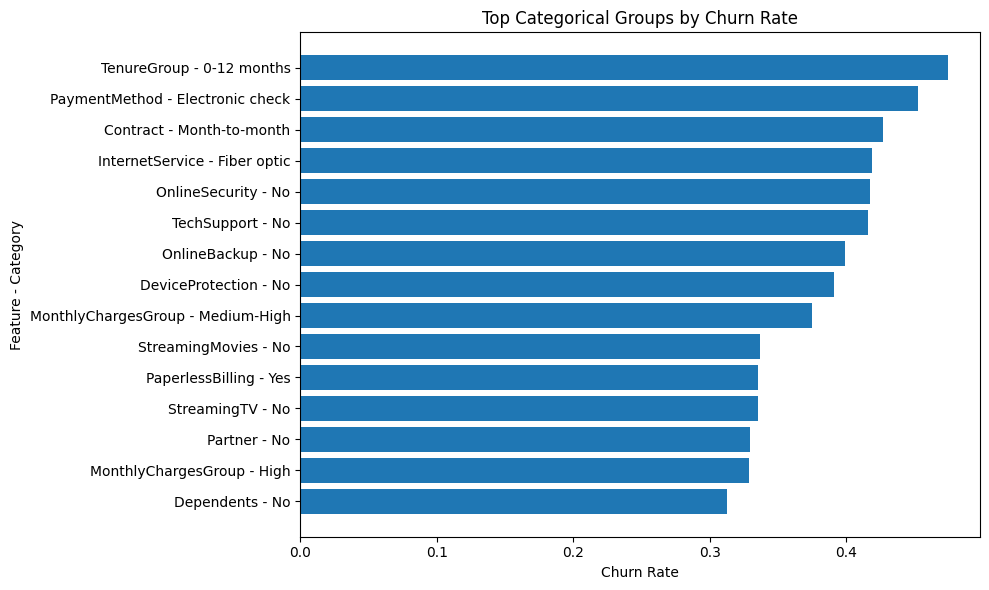

In [ ]:
import matplotlib.pyplot as plt

top_categories = categorical_churn_df.sort_values(
    'ChurnRate',
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories['Feature'] + ' - ' + top_categories['Category'],
    top_categories['ChurnRate']
)

plt.xlabel('Churn Rate')
plt.ylabel('Feature - Category')
plt.title('Top Categorical Groups by Churn Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
print("Churn distribution:")
print(df['Churn'].value_counts())

print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True).round(3))

# Check missing values
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn percentage:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Missing values:
TotalCharges        11
gender               0
customerID           0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
SeniorCitizen        0
OnlineBackup         0
DeviceProtection     0
StreamingTV          0
TechSupport          0
dtype: int64


In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7043, 26)
y shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
print(df[engineered_features].dtypes)

AvgMonthlyCharge     float64
ChargeDifference     float64
TotalServices          int64
TenureGroup         category
dtype: object


In [ ]:
print([col for col in service_columns if col not in df.columns])

['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [ ]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060

In [ ]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
print(df.shape)

(7043, 21)


In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

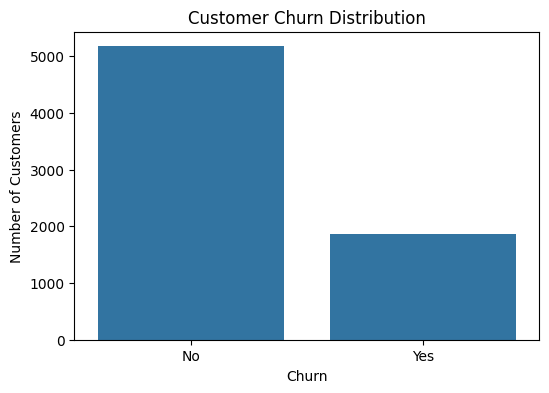

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


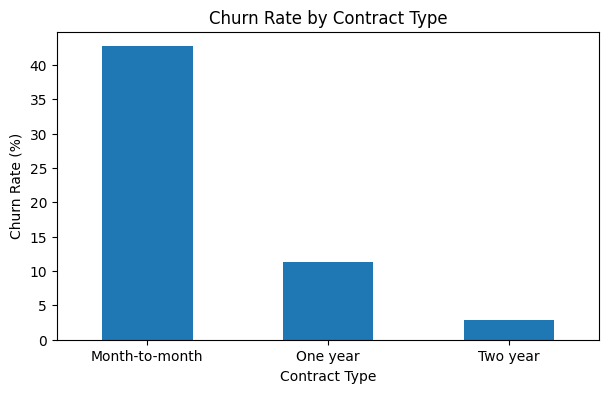

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn["Yes"].sort_values(ascending=False)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Yes, dtype: float64

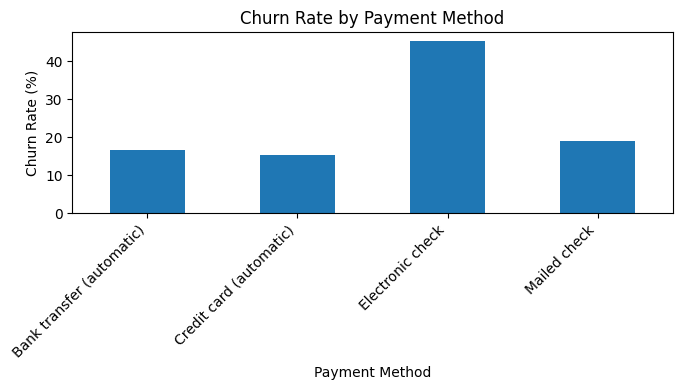

In [ ]:
payment_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
tenure_churn = df.groupby("Churn")["tenure"].mean()
tenure_churn

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

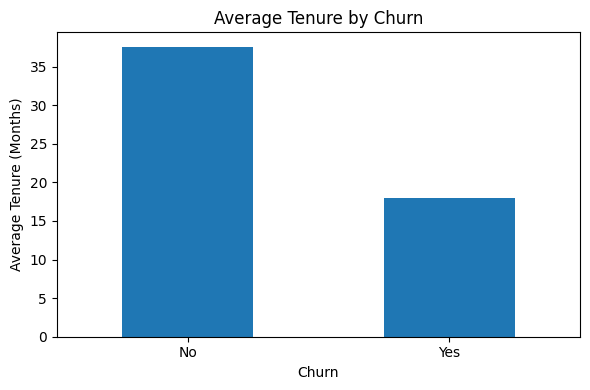

In [ ]:
tenure_churn.plot(kind="bar", figsize=(6, 4))

plt.title("Average Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()
monthly_charges_churn

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

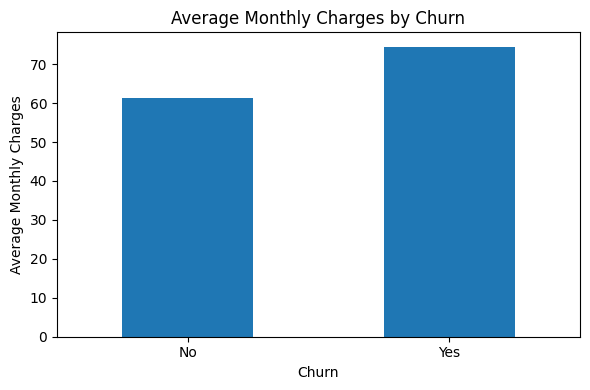

In [ ]:
monthly_charges_churn.plot(kind="bar", figsize=(6, 4))

plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


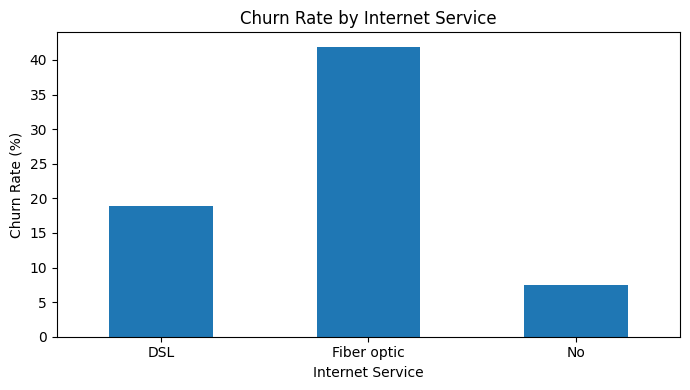

In [ ]:
internet_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


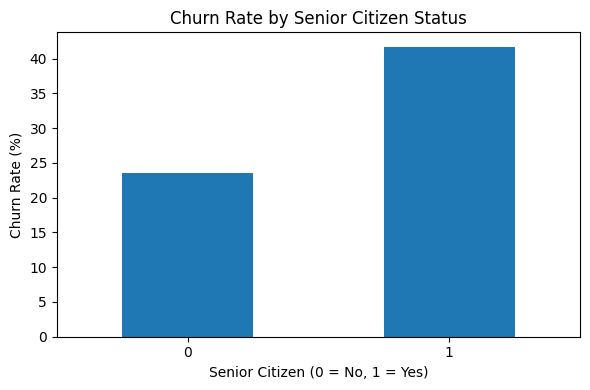

In [ ]:
senior_churn["Yes"].plot(kind="bar", figsize=(6, 4))

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


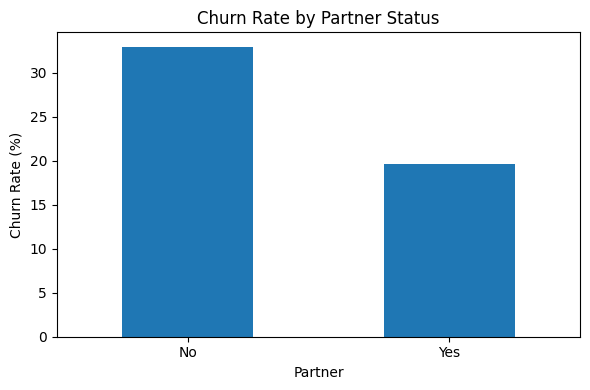

In [ ]:
partner_churn["Yes"].plot(kind="bar", figsize=(6, 4))

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


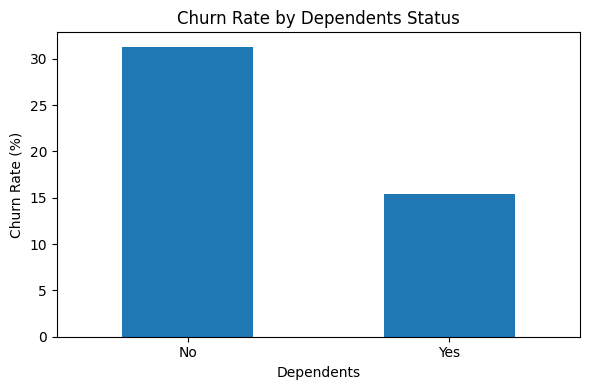

In [ ]:
dependents_churn["Yes"].plot(kind="bar", figsize=(6, 4))

plt.title("Churn Rate by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


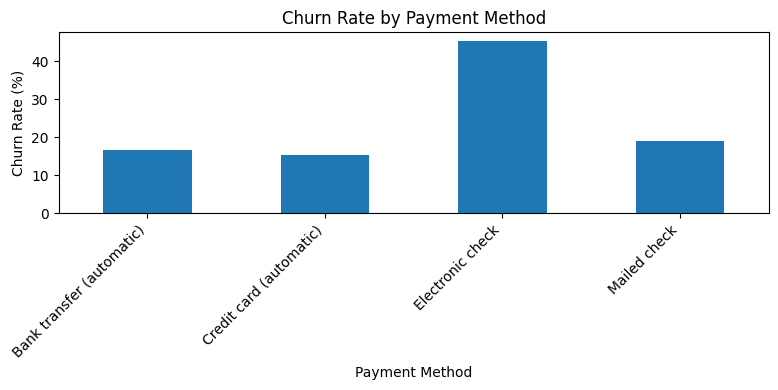

In [ ]:
payment_churn["Yes"].plot(kind="bar", figsize=(8, 4))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


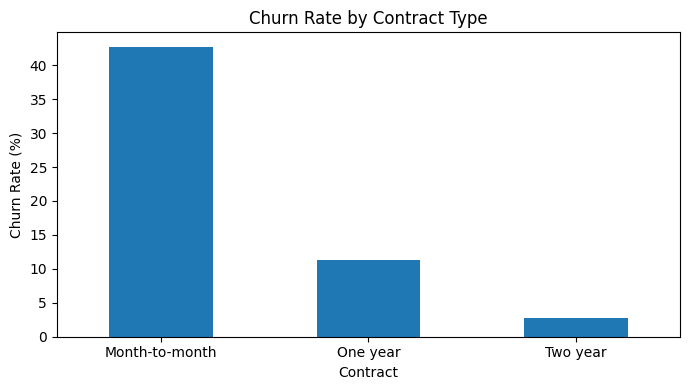

In [ ]:
contract_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


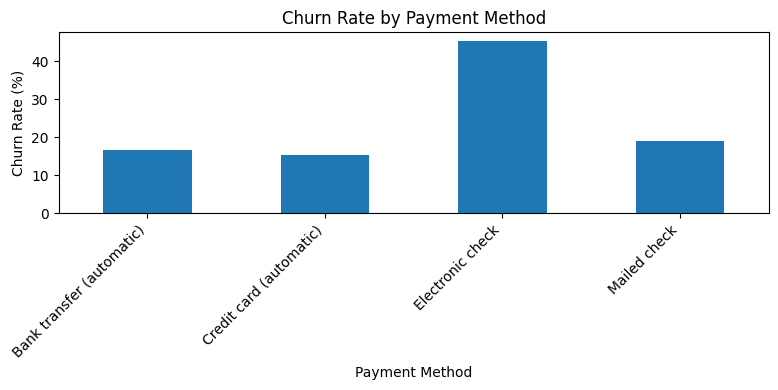

In [ ]:
payment_churn["Yes"].plot(kind="bar", figsize=(8, 4))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
tenure_churn = df.groupby("Churn")["tenure"].mean()

tenure_churn

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

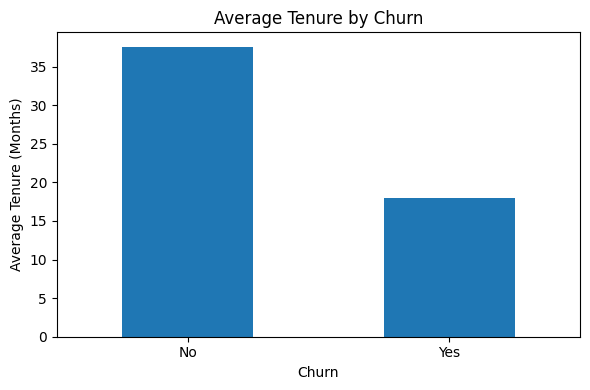

In [ ]:
tenure_churn.plot(kind="bar", figsize=(6, 4))

plt.title("Average Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges          str
dtype: object

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.5
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [ ]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges          str
dtype: object

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].head(10)

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.5
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
5,8,99.65,820.5
6,22,89.10,1949.4
7,10,29.75,301.9
8,28,104.80,3046.05
9,62,56.15,3487.95


In [ ]:
df["TotalCharges"].astype(str).str.strip().value_counts().head(10)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
Name: count, dtype: int64

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges          str
dtype: object

In [ ]:
df["TotalCharges"].astype(str).str.strip().eq("").sum()

np.int64(11)

In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df["TotalCharges"].astype(str).str.strip() == ""][[
    "customerID",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip(),
    errors="coerce"
)

# For customers with tenure = 0, TotalCharges should be 0
df.loc[
    df["TotalCharges"].isna() & (df["tenure"] == 0),
    "TotalCharges"
] = 0.0

# Verify
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())
print("TotalCharges dtype:", df["TotalCharges"].dtype)

df[df["tenure"] == 0][[
    "customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"
]].head(15)

Missing TotalCharges: 0
TotalCharges dtype: float64


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
import os

os.makedirs("data/processed", exist_ok=True)

df.to_csv(
    "data/processed/telco_customer_churn_clean.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset saved successfully.
Rows: 7043
Columns: 7079


In [ ]:
import os

os.makedirs("data/processed", exist_ok=True)

In [ ]:
df.to_csv(
    "data/processed/telco_customer_churn_clean.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset saved successfully.
Rows: 7043
Columns: 21


In [ ]:
import pandas as pd

df = pd.read_csv("data/processed/telco_customer_churn_clean.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Churn value counts:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060

In [ ]:
print([repr(col) for col in df.columns])

["'SeniorCitizen'", "'tenure'", "'MonthlyCharges'", "'TotalCharges'", "'IsLongTermCustomer'", "'customerID_0003-MKNFE'", "'customerID_0004-TLHLJ'", "'customerID_0011-IGKFF'", "'customerID_0013-EXCHZ'", "'customerID_0013-MHZWF'", "'customerID_0013-SMEOE'", "'customerID_0014-BMAQU'", "'customerID_0015-UOCOJ'", "'customerID_0016-QLJIS'", "'customerID_0017-DINOC'", "'customerID_0017-IUDMW'", "'customerID_0018-NYROU'", "'customerID_0019-EFAEP'", "'customerID_0019-GFNTW'", "'customerID_0020-INWCK'", "'customerID_0020-JDNXP'", "'customerID_0021-IKXGC'", "'customerID_0022-TCJCI'", "'customerID_0023-HGHWL'", "'customerID_0023-UYUPN'", "'customerID_0023-XUOPT'", "'customerID_0027-KWYKW'", "'customerID_0030-FNXPP'", "'customerID_0031-PVLZI'", "'customerID_0032-PGELS'", "'customerID_0036-IHMOT'", "'customerID_0040-HALCW'", "'customerID_0042-JVWOJ'", "'customerID_0042-RLHYP'", "'customerID_0048-LUMLS'", "'customerID_0048-PIHNL'", "'customerID_0052-DCKON'", "'customerID_0052-YNYOT'", "'customerID_00

In [ ]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060

In [ ]:
print("Columns containing 'churn':")

for col in df.columns:
    if "churn" in str(col).lower():
        print(repr(col))

Columns containing 'churn':
'Churn_Yes'


In [ ]:
X = df.drop(columns=["Churn_Yes"])
y = df["Churn_Yes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (7043, 7078)
y shape: (7043,)

Target values:
Churn_Yes
False    5174
True     1869
Name: count, dtype: int64


In [ ]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (5634, 7078)
Testing set: (1409, 7078)

Training target:
Churn_Yes
False    4139
True     1495
Name: count, dtype: int64

Testing target:
Churn_Yes
False    1035
True      374
Name: count, dtype: int64


In [ ]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.model_selection import train_test_split
print("scikit-learn works!")

scikit-learn works!


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns=["Churn_Yes"])
y = df["Churn_Yes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 7078)
y shape: (7043,)


In [ ]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (5634, 7078)
Testing set: (1409, 7078)

Training target:
Churn_Yes
False    4139
True     1495
Name: count, dtype: int64

Testing target:
Churn_Yes
False    1035
True      374
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=["Churn_Yes"])
y = df["Churn_Yes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (7043, 7078)
y shape: (7043,)

Target values:
Churn_Yes
False    5174
True     1869
Name: count, dtype: int64


In [ ]:
print("Number of features:", X.shape[1])

print("First 20 feature names:")
print(X.columns.tolist()[:20])

print("\nFeatures containing customerID:")
print([col for col in X.columns if "customer" in str(col).lower()])

Number of features: 7078
First 20 feature names:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK']

Features containing customerID:
['IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID

In [ ]:
customer_cols = [
    col for col in X.columns
    if "customerid" in str(col).lower()
]

print("Customer ID columns to remove:", len(customer_cols))

X = X.drop(columns=customer_cols)

print("Features after removing customer ID columns:", X.shape[1])

Customer ID columns to remove: 7042
Features after removing customer ID columns: 36


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (5634, 36)
Testing set: (1409, 36)

Training target:
Churn_Yes
False    4139
True     1495
Name: count, dtype: int64

Testing target:
Churn_Yes
False    1035
True      374
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object", "bool"]).columns

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Numeric columns: 6
Categorical columns: 30
Processed training shape: (5634, 66)
Processed testing shape: (1409, 66)


In [ ]:
import pandas as pd

df = pd.read_csv("data/processed/telco_customer_churn_clean.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [ ]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.1
NumPy version: 2.4.3


In [ ]:
from pathlib import Path

csv_files = list(Path.cwd().rglob("*.csv"))

print("Number of CSV files found:", len(csv_files))

for f in csv_files:
    print(f)

Number of CSV files found: 1
c:\Users\tamir\OneDrive\Documents\Zaalima-Data-Analytics-Team\notebooks\data\processed\telco_customer_churn_clean.csv


In [ ]:
df_original = pd.read_csv(csv_files[0])

print("Data loaded successfully!")
print("Shape:", df_original.shape)
print("Columns:")
print(df_original.columns.tolist())

Data loaded successfully!
Shape: (7043, 21)
Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
from pathlib import Path

files = list(Path.cwd().rglob("Telco*Churn.csv"))

print("Files found:")
for f in files:
    print(f)

Files found:


In [28]:
from pathlib import Path

print("Current folder:")
print(Path.cwd())

print("\nCSV files found:")
for f in Path.cwd().rglob("*.csv"):
    print(f)

Current folder:
c:\Users\tamir\OneDrive\Documents\Zaalima-Data-Analytics-Team\notebooks

CSV files found:
c:\Users\tamir\OneDrive\Documents\Zaalima-Data-Analytics-Team\notebooks\data\processed\telco_customer_churn_clean.csv


In [16]:
from pathlib import Path
import pandas as pd

In [17]:
csv_files = list(Path.cwd().rglob("*.csv"))

print("Number of CSV files found:", len(csv_files))

for f in csv_files:
    print(f)

Number of CSV files found: 1
c:\Users\tamir\OneDrive\Documents\Zaalima-Data-Analytics-Team\notebooks\data\processed\telco_customer_churn_clean.csv


In [30]:
import pandas as pd

In [18]:
df_original = pd.read_csv(csv_files[0])

print("Data loaded successfully!")
print("Shape:", df_original.shape)
print("Columns:")
print(df_original.columns.tolist())

Data loaded successfully!
Shape: (7043, 21)
Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'IsLongTermCustomer', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060

In [19]:
X = df_original.drop(columns=["Churn", "customerID"])
y = df_original["Churn"].map({"No": 0, "Yes": 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [ ]:
y = y.map({"No": 0, "Yes": 1})

print("Target distribution:")
print(y.value_counts())

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Remove ID column if it exists
X = X.drop(columns=["customerID"], errors="ignore")

# Convert categorical columns to numbers
X_encoded = pd.get_dummies(X, drop_first=True)

# Split the encoded data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


In [54]:
# Convert target variables to integer for XGBoost
y_train_xgb = y_train.astype(int)
y_test_xgb = y_test.astype(int)

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

print("Numeric features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\tamir\AppData\Local\Temp\ipykernel_25620\3022019083.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (5634, 45)
Processed X_test shape: (1409, 45)


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Train ONLY on training data
logreg.fit(X_train_processed, y_train)
# Predict on test data
y_pred_logreg = logreg.predict(X_test_processed)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

Logistic Regression Accuracy: 0.8055358410220014

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
[[926 109]
 [165 209]]


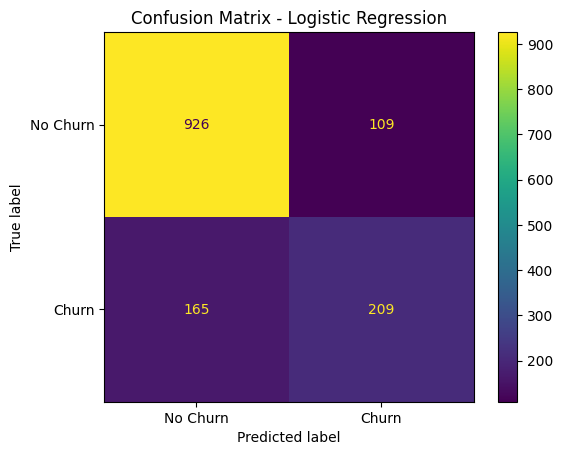

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logreg)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Logistic Regression ROC-AUC: 0.8427290810922524


c:\Users\tamir\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


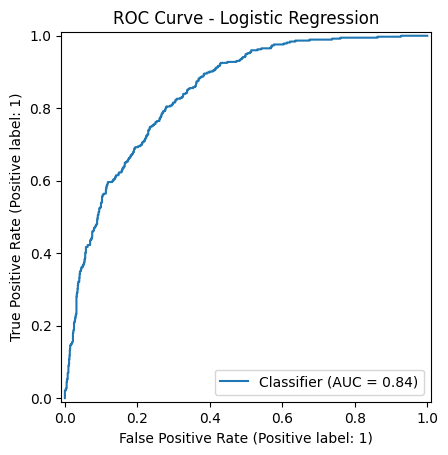

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

# Logistic Regression probabilities
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# ROC-AUC
lr_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression ROC-AUC:", lr_auc)

# ROC Curve
RocCurveDisplay.from_predictions(y_test, lr_prob)
plt.title("ROC Curve - Logistic Regression")
plt.show()

### Logistic Regression Results

The Logistic Regression model achieved an accuracy of approximately 80.0% on the test dataset.

The confusion matrix shows that:
- 926 customers were correctly predicted as No Churn.
- 209 customers were correctly predicted as Churn.
- 109 No Churn customers were incorrectly predicted as Churn.
- 165 Churn customers were incorrectly predicted as No Churn.

The model performs reasonably well overall, but it has difficulty identifying some customers who actually churn.

In [41]:
[name for name in globals() if "rf" in name.lower() or "forest" in name.lower()]

[]

## Random Forest Model

A Random Forest classifier is trained to predict customer churn. 
The model uses multiple decision trees and class weighting to handle 
the imbalance between churn and non-churn customers.

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, rf_pred))

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

Random Forest Accuracy: 0.7743080198722498

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.57      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409

Random Forest ROC-AUC: 0.8275013562737348


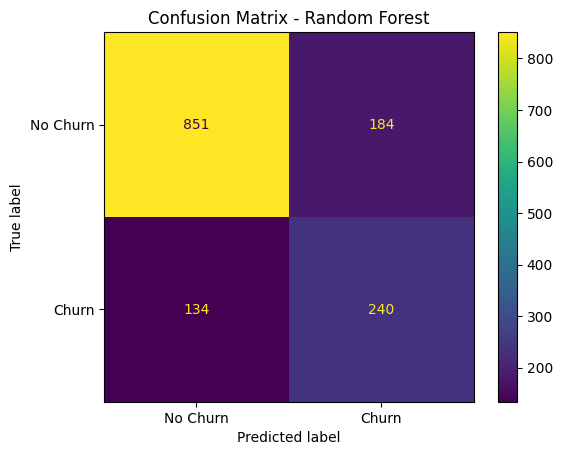

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

Random Forest ROC-AUC: 0.8275013562737348


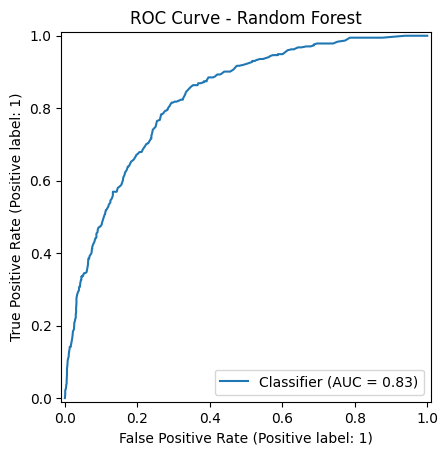

In [53]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

RocCurveDisplay.from_predictions(y_test, rf_prob)
plt.title("ROC Curve - Random Forest")
plt.show()

In [56]:
# Encode target variable for XGBoost
y_train_xgb = y_train.map({"No": 0, "Yes": 1})
y_test_xgb = y_test.map({"No": 0, "Yes": 1})

In [ ]:
%pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [21]:
# Remove rows where the target is missing
train_mask = y_train.notna()

X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]

print(y_train.isna().sum())
print(y_train.unique())

0
[0 1]


In [23]:
# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Probability for positive class
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7991483321504613
XGBoost ROC-AUC: 0.8444018186984937

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [24]:
print(y_train.unique())
print(y_train.value_counts(dropna=False))

[0 1]
Churn
0    4139
1    1495
Name: count, dtype: int64


In [25]:
y_train_xgb = y_train.astype(int)
y_test_xgb = y_test.astype(int)

In [26]:
xgb_model.fit(X_train, y_train_xgb)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [27]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Probability for positive class
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [28]:
print("XGBoost Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test_xgb, y_prob_xgb))

print("\nXGBoost Classification Report:")
print(classification_report(y_test_xgb, y_pred_xgb))

XGBoost Accuracy: 0.7991483321504613
XGBoost ROC-AUC: 0.8444018186984937

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



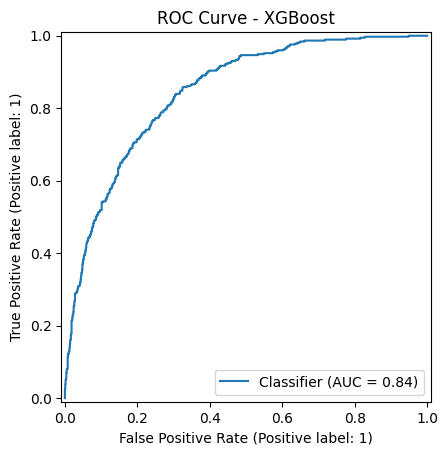

In [29]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test_xgb, y_prob_xgb)

plt.title("ROC Curve - XGBoost")
plt.show()

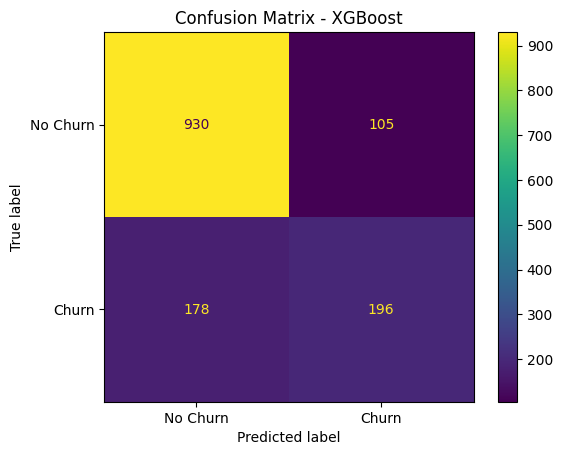

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [55]:
print("Number of features:", xgb_model.n_features_in_)
print("Feature names:", xgb_model.feature_names_in_)

Number of features: 30
Feature names: ['SeniorCitizen' 'tenure' 'MonthlyCharges' 'TotalCharges' 'gender_Male'
 'Partner_Yes' 'Dependents_Yes' 'PhoneService_Yes'
 'MultipleLines_No phone service' 'MultipleLines_Yes'
 'InternetService_Fiber optic' 'InternetService_No'
 'OnlineSecurity_No internet service' 'OnlineSecurity_Yes'
 'OnlineBackup_No internet service' 'OnlineBackup_Yes'
 'DeviceProtection_No internet service' 'DeviceProtection_Yes'
 'TechSupport_No internet service' 'TechSupport_Yes'
 'StreamingTV_No internet service' 'StreamingTV_Yes'
 'StreamingMovies_No internet service' 'StreamingMovies_Yes'
 'Contract_One year' 'Contract_Two year' 'PaperlessBilling_Yes'
 'PaymentMethod_Credit card (automatic)' 'PaymentMethod_Electronic check'
 'PaymentMethod_Mailed check']


In [2]:
import shap

c:\Users\tamir\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [66]:
%pip install shap

   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   -- ------------------------------------- 41.0/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 71.7/554.9 kB 2.


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import shap

In [31]:
# SHAP Explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 30)


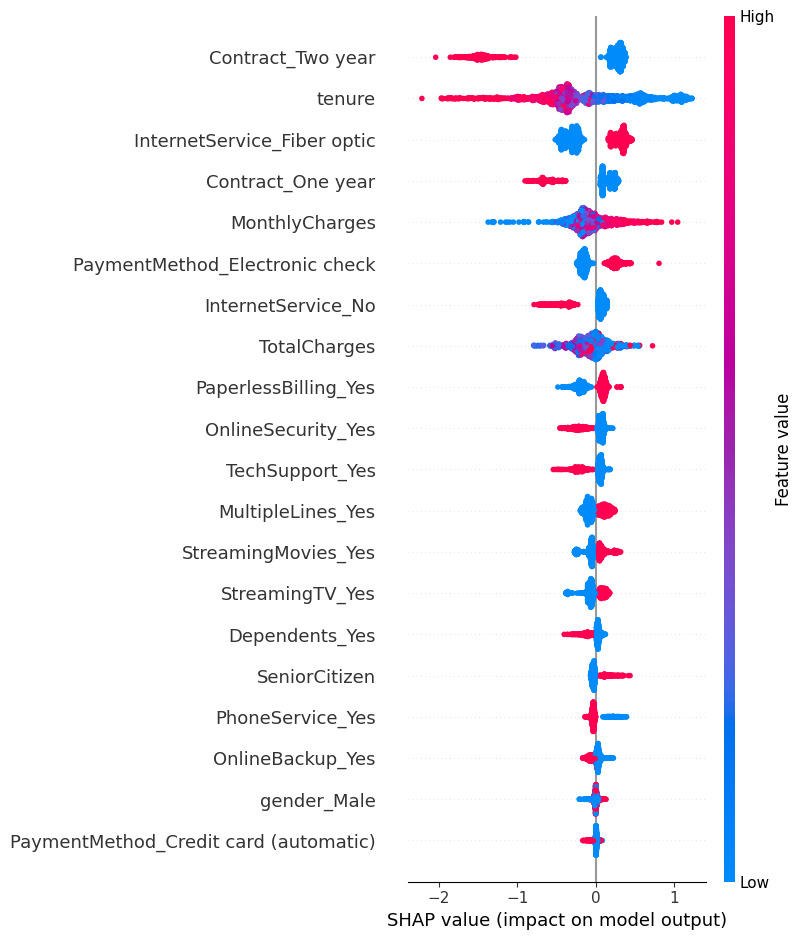

In [69]:
# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

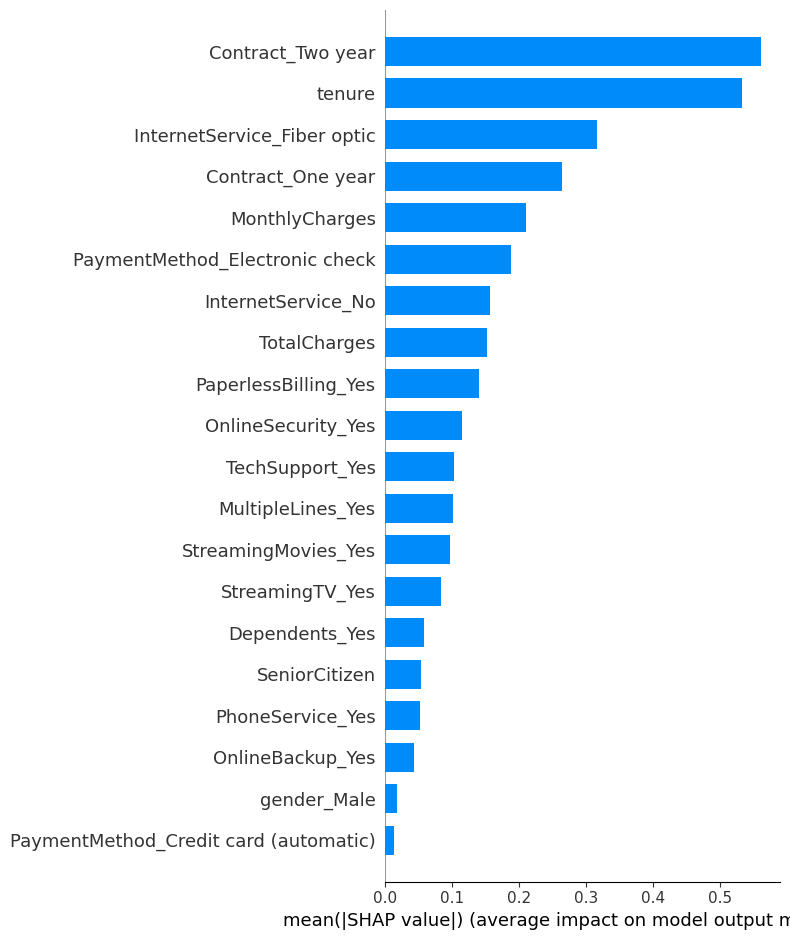

In [70]:
# SHAP Feature Importance
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    plot_type="bar"
)

### SHAP Feature Importance – Business Interpretation

The SHAP analysis shows which customer characteristics have the greatest influence
on the XGBoost churn predictions.

The most influential features are contract type, tenure, internet service type,
monthly charges, and payment method.

Contract type and customer tenure are particularly important predictors of churn.
This suggests that customers with shorter or less committed contracts may require
greater retention attention.

Monthly charges and payment method also contribute significantly to the model's
predictions, indicating that pricing and payment behaviour may be relevant factors
in customer churn.

These insights can help the business identify high-risk customer segments and
design targeted retention strategies.

### SHAP Analysis – Business Interpretation

The SHAP analysis shows which features have the greatest influence on the XGBoost churn prediction.

The most important features identified by the model are:

1. *Contract_Two year* – one of the strongest predictors of churn.
2. *tenure* – customer length of relationship has a major influence on predictions.
3. *InternetService_Fiber optic* – has a significant impact on churn predictions.
4. *Contract_One year* – also contributes strongly to the model's predictions.
5. *MonthlyCharges* – higher/lower monthly charges influence churn likelihood.

These results suggest that customer contract type, tenure, internet service type, and monthly charges are important factors when identifying customers at risk of churn.

From a business perspective, the company can use these insights to identify high-risk customers and develop targeted retention strategies, such as personalized offers, contract incentives, and proactive customer support.

# Week 3: LTV Calculation & Regression Modeling

## Day 1: Lifetime Value (LTV) Calculation

The objective of Week 3 is to estimate the expected lifetime revenue of active customers
and develop regression models that can predict customer lifetime value.

In [32]:
# Inspect the variables relevant to Lifetime Value (LTV)

ltv_columns = [
    'customerID',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Churn'
]

df_original[ltv_columns].head(10)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,29.85,29.85,No
1,5575-GNVDE,34,56.95,1889.50,No
2,3668-QPYBK,2,53.85,108.15,Yes
3,7795-CFOCW,45,42.30,1840.75,No
4,9237-HQITU,2,70.70,151.65,Yes
5,9305-CDSKC,8,99.65,820.50,Yes
6,1452-KIOVK,22,89.10,1949.40,No
7,6713-OKOMC,10,29.75,301.90,No
8,7892-POOKP,28,104.80,3046.05,Yes
9,6388-TABGU,62,56.15,3487.95,No


In [33]:
# Select active customers
df_active = df_original[df_original['Churn'] == 'No'].copy()

print("Total customers:", len(df_original))
print("Active customers:", len(df_active))
print("Churned customers:", (df_original['Churn'] == 'Yes').sum())

Total customers: 7043
Active customers: 5174
Churned customers: 1869


In [34]:
# Check LTV-related columns for missing values

print(df_active[['tenure', 'MonthlyCharges', 'TotalCharges']].isnull().sum())

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [35]:
# Check data types

print(df_active[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes)

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object


In [36]:
df_active['TotalCharges'] = pd.to_numeric(
    df_active['TotalCharges'],
    errors='coerce'
)

In [38]:
print(df_active[['tenure', 'MonthlyCharges', 'TotalCharges']].isnull().sum())

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [39]:
# Descriptive statistics for LTV-related variables

df_active[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,5174.000000,5174.000000,5174.000000
mean,37.569965,61.265124,2549.911442
std,24.113777,31.092648,2329.954215
min,0.000000,18.250000,0.000000
25%,15.000000,25.100000,572.900000
50%,38.000000,64.425000,1679.525000
75%,61.000000,88.400000,4262.850000
max,72.000000,118.750000,8672.450000


In [40]:
# Correlation between tenure, monthly charges and total charges

df_active[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.330892,0.793745
MonthlyCharges,0.330892,1.000000,0.756874
TotalCharges,0.793745,0.756874,1.000000


## LTV Target Definition

The dataset does not contain future customer revenue, so a true prospective
Customer Lifetime Value cannot be directly observed.

For this analysis, TotalCharges is used as a historical LTV proxy,
representing the total revenue generated by the customer to date.

The regression models will estimate this lifetime revenue using available
customer characteristics.

In [41]:
# Create the LTV target

df_active['LTV'] = df_active['TotalCharges']

print("LTV target created successfully")
print(df_active['LTV'].describe())

LTV target created successfully
count    5174.000000
mean     2549.911442
std      2329.954215
min         0.000000
25%       572.900000
50%      1679.525000
75%      4262.850000
max      8672.450000
Name: LTV, dtype: float64


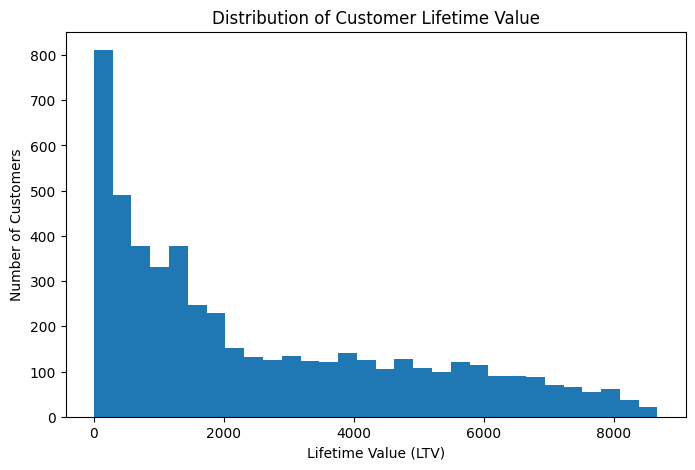

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_active['LTV'], bins=30)
plt.xlabel('Lifetime Value (LTV)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Lifetime Value')
plt.show()

In [43]:
print("Negative LTV:", (df_active['LTV'] < 0).sum())
print("Zero LTV:", (df_active['LTV'] == 0).sum())
print("Total active customers:", len(df_active))

Negative LTV: 0
Zero LTV: 11
Total active customers: 5174


In [44]:
# Prepare features for LTV regression

# Copy the active customer dataset
df_ltv = df_active.copy()

# Define target
y = df_ltv['LTV']

# Remove columns that should NOT be used as predictors
X = df_ltv.drop(
    columns=['LTV', 'TotalCharges', 'customerID', 'Churn'],
    errors='ignore'
)

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("LTV")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges']

Target:
LTV

Feature shape: (5174, 18)
Target shape: (5174,)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4139
Testing samples: 1035


In [46]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\tamir\AppData\Local\Temp\ipykernel_712\880427887.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            'passthrough',
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
-------------------------
MAE : 552.9264625792335
RMSE: 672.7572701594751
R²  : 0.9167689491476333


In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully.")

Random Forest Regression model trained successfully.


In [51]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Results
--------------------------------
MAE : 58.185203302852656
RMSE: 84.01575910170456
R²  : 0.9987019539797266


In [52]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regression'
    ],
    'MAE': [
        mae_linear,
        mae_rf
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf
    ],
    'R2': [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,552.926463,672.757270,0.916769
1,Random Forest Regression,58.185203,84.015759,0.998702


### Model Comparison – LTV Prediction

Two regression models were evaluated for predicting customer Lifetime Value (LTV):
Linear Regression and Random Forest Regression.

Random Forest Regression performed substantially better than Linear Regression.

- Linear Regression:
  - MAE: 552.93
  - RMSE: 672.76
  - R²: 0.9168

- Random Forest Regression:
  - MAE: 58.19
  - RMSE: 84.02
  - R²: 0.9987

The Random Forest model was selected as the stronger model because it produced
much lower MAE and RMSE values and a substantially higher R² score.

This indicates that the relationship between customer characteristics and LTV
is highly non-linear and is captured much more effectively by the Random Forest
model than by Linear Regression.

In [53]:
import joblib

joblib.dump(xgb_model, "xgboost_churn_model.pkl")

['xgboost_churn_model.pkl']